In [68]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import sympy as sp
import numpy as np

**Упражнение 1**

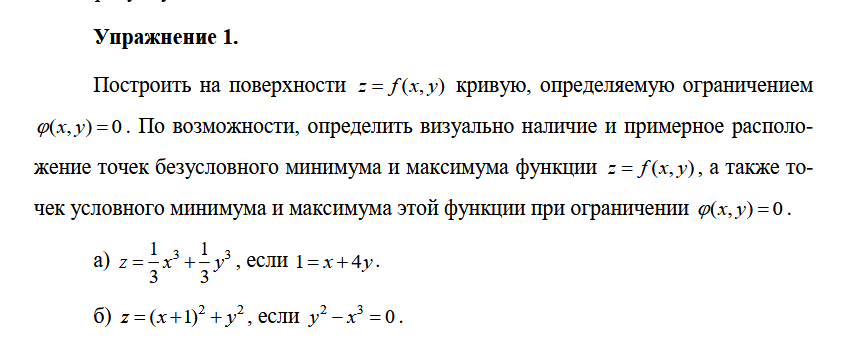

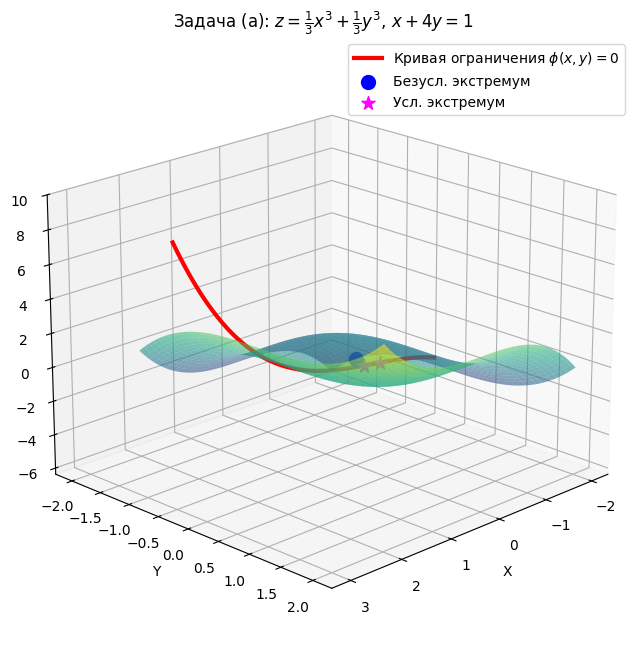

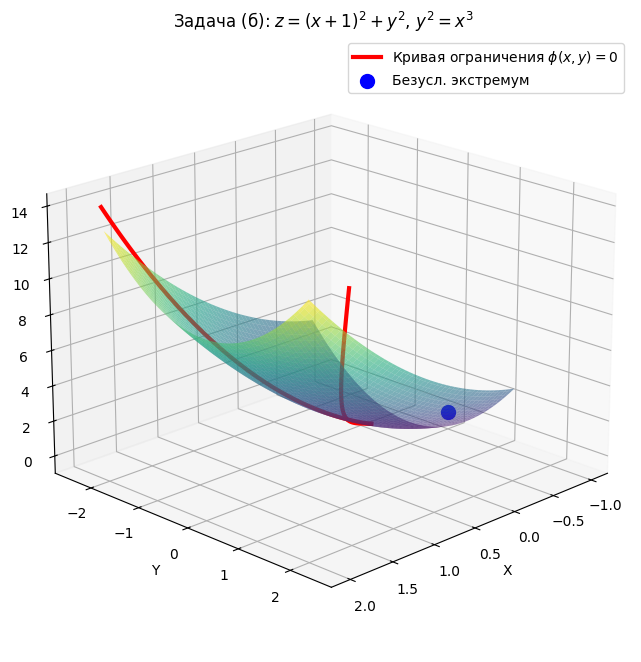

In [17]:
def solve_task(task_id):
    x, y, lam = sp.symbols('x y lam', real=True)
    
    if task_id == 'a':
        f_expr = (1/3)*x**3 + (1/3)*y**3
        phi_expr = x + 4*y - 1
        title = "Задача (а): $z = \\frac{1}{3}x^3 + \\frac{1}{3}y^3$, $x + 4y = 1$"
        x_range = np.linspace(-2, 2, 100)
        y_range = np.linspace(-2, 2, 100)
    else:
        f_expr = (x + 1)**2 + y**2
        phi_expr = y**2 - x**3
        title = "Задача (б): $z = (x+1)^2 + y^2$, $y^2 = x^3$"
        x_range = np.linspace(-0.5, 2, 100)
        y_range = np.linspace(-2, 2, 100)

    f_grad = [sp.diff(f_expr, var) for var in (x, y)]
    uncond_pts = sp.solve(f_grad, (x, y), dict=True)
    
    L = f_expr + lam * phi_expr
    L_grad = [sp.diff(L, var) for var in (x, y, lam)]
    cond_pts = sp.solve(L_grad, (x, y, lam), dict=True)

    X, Y = np.meshgrid(x_range, y_range)
    f_func = sp.lambdify((x, y), f_expr, 'numpy')
    Z = f_func(X, Y)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, antialiased=True)
    
    if task_id == 'a':
        y_c = np.linspace(-0.5, 0.5, 100)
        x_c = 1 - 4*y_c
    else:
        x_c = np.linspace(0, 1.8, 100)
        y_c = x_c**(1.5)
        ax.plot(x_c, -y_c, f_func(x_c, -y_c), color='red', lw=3) 
        
    z_c = f_func(x_c, y_c)
    ax.plot(x_c, y_c, z_c, color='red', lw=3, label=r'Кривая ограничения $\phi(x,y)=0$')

    for pt in uncond_pts:
        zv = float(f_expr.subs(pt))
        ax.scatter(float(pt[x]), float(pt[y]), zv, color='blue', s=100, label='Безусл. экстремум')

    for pt in cond_pts:
        zv = float(f_expr.subs({x: pt[x], y: pt[y]}))
        ax.scatter(float(pt[x]), float(pt[y]), zv, color='magenta', s=100, marker='*', label='Усл. экстремум')

    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=20, azim=45)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

    plt.show()

solve_task('a')
solve_task('b')

**Упражнение 2**

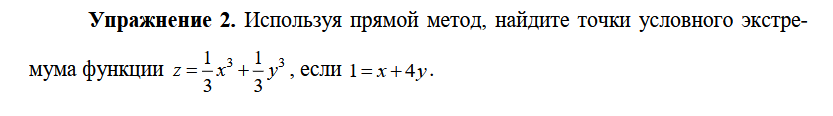

In [ ]:
import sympy as sp

x, y = sp.symbols('x y', real=True)
f = (1/3)*x**3 + (1/3)*y**3
constraint = x + 4*y - 1 

x_expr = sp.solve(constraint, x)[0]
print(f"Выражение для x: {x_expr}")
f_y = f.subs(x, x_expr)
print(f"Функция от одной переменной y: {f_y}")

df_dy = sp.diff(f_y, y)
y_coords = sp.solve(df_dy, y)

print("\nНайденные точки условного экстремума:")
for y_val in y_coords:
    x_val = x_expr.subs(y, y_val)
    z_val = f_y.subs(y, y_val)
    
    d2f_dy2 = sp.diff(df_dy, y).subs(y, y_val)
    kind = "Локальный минимум" if d2f_dy2 > 0 else "Локальный максимум" if d2f_dy2 < 0 else "Седловая точка/неопределено"
    
    print(f"Точка P(x={x_val}, y={y_val})")
    print(f"  Значение z = {z_val}")
    print(f"  Тип: {kind}")
    print("-" * 30)

Выражение для x: 1 - 4*y
Функция от одной переменной y: 0.333333333333333*y**3 + 0.333333333333333*(1 - 4*y)**3

Найденные точки условного экстремума:
Точка P(x=0.111111111111111, y=0.222222222222222)
  Значение z = 0.00411522633744856
  Тип: Локальный минимум
------------------------------
Точка P(x=-0.142857142857143, y=0.285714285714286)
  Значение z = 0.00680272108843537
  Тип: Локальный максимум
------------------------------


**Упражнение 3, 4** 

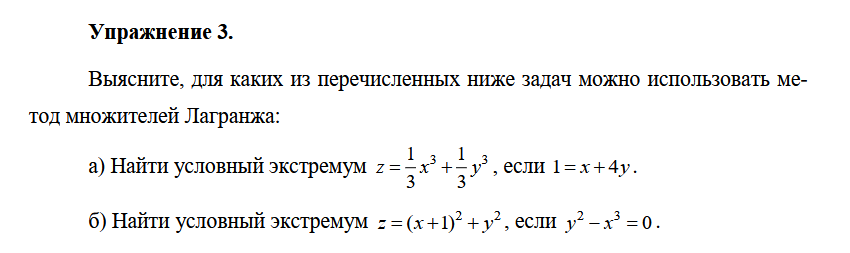

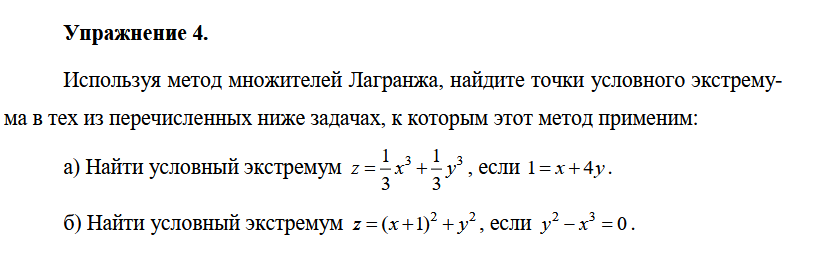

In [42]:
import sympy as sp

def check_lagrange_applicability(f_expr, phi_expr, label):
    x, y, lam = sp.symbols('x y lam')
    
    grad_phi = [sp.diff(phi_expr, var) for var in (x, y)]
    
    if all(g == 0 for g in grad_phi):
        print(f"Градиент ограничения везде нулевой для задачи {label}. Метод Лагранжа неприменим.")
        return

    L = f_expr + lam * phi_expr
    system = [sp.diff(L, v) for v in (x, y, lam)]
    solutions = sp.solve(system, (x, y, lam), dict=True)
    
    print(f"--- Анализ задачи {label} ---")
    print(f"Градиент ограничения: {grad_phi}")
    
    if not solutions:
        print("Решений системы Лагранжа не найдено.")
        return

    for sol in solutions:
        if sum([type(i) == sp.RealNumber for _, i in sol.items()]) == 0:
            print(f"Найдены комплексные решения для задачи {label}. Метод Лагранжа неприменим для этих решений.")
            continue

        g_val = [float(g.subs({x: sol[x], y: sol[y]})) for g in grad_phi]
        is_regular = not (g_val[0] == 0 or g_val[1] == 0)
        if not is_regular:
            print(f"Градиент ограничения в точке (x={sol[x]}, y={sol[y]}) равен нулю. Метод Лагранжа неприменим для этой точки.")
            continue

        print(f"Точка: (x={sol[x]}, y={sol[y]})")
        print(f"Градиент phi в этой точке: {g_val}")
        print(f"Условие регулярности (grad phi != 0): {is_regular}")
        if is_regular:
            subss = {x: sol[x], y: sol[y], lam: sol[lam]}
            matr = sp.Matrix([[0, sp.diff(phi_expr, x).subs(subss), sp.diff(phi_expr, y).subs(subss)],
                              [sp.diff(phi_expr, x).subs(subss), sp.diff(L, x, x).subs(subss), L.diff(x, y).subs(subss)],
                              [sp.diff(phi_expr, y).subs(subss), sp.diff(L, x, y).subs(subss), sp.diff(L, y, y).subs(subss)]])
            det = -matr.det()
            if det > 0:
                print("Условный минимум.")
            elif det < 0:
                print("Условный максимум.")
            print(f_expr.subs({x: sol[x], y: sol[y]}))
        print("-" * 20)

x, y = sp.symbols('x y')
check_lagrange_applicability((1/3)*x**3 + (1/3)*y**3, x + 4*y - 1, "а")
check_lagrange_applicability((x + 1)**2 + y**2, y**2 - x**3, "б")

--- Анализ задачи а ---
Градиент ограничения: [1, 4]
Точка: (x=-0.142857142857143, y=0.285714285714286)
Градиент phi в этой точке: [1.0, 4.0]
Условие регулярности (grad phi != 0): True
Условный максимум.
0.00680272108843537
--------------------
Точка: (x=0.111111111111111, y=0.222222222222222)
Градиент phi в этой точке: [1.0, 4.0]
Условие регулярности (grad phi != 0): True
Условный минимум.
0.00411522633744856
--------------------
--- Анализ задачи б ---
Градиент ограничения: [-3*x**2, 2*y]
Найдены комплексные решения для задачи б. Метод Лагранжа неприменим для этих решений.
Найдены комплексные решения для задачи б. Метод Лагранжа неприменим для этих решений.
Найдены комплексные решения для задачи б. Метод Лагранжа неприменим для этих решений.
Найдены комплексные решения для задачи б. Метод Лагранжа неприменим для этих решений.


**Упражнение 5**

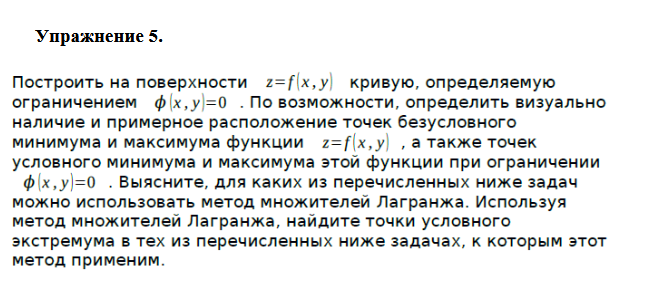

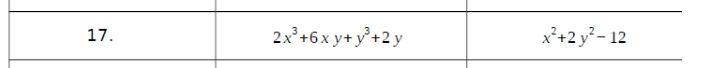

         x |          y |          z | Тип
--------------------------------------------------
   -3.4121 |     0.4227 |   -87.1855 | Условный минимум
    3.3772 |     0.5452 |    89.3375 | Условный максимум
   -1.6039 |    -2.1711 |    -1.9349 | Условный максимум
    1.1376 |    -2.3136 |   -29.8596 | Условный минимум


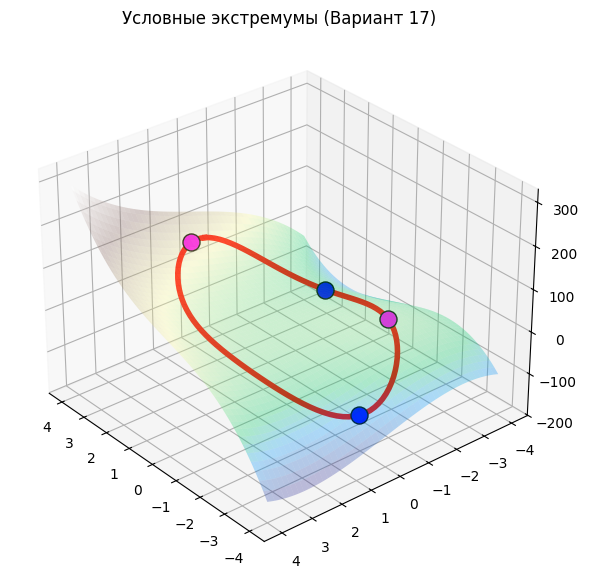

In [ ]:
def f(params):
    x, y = params
    return 2*x**3 + 6*x*y + y**3 + 2*y

def constraint(params):
    x, y = params
    return x**2 + 2*y**2 - 12

cons = ({'type': 'eq', 'fun': constraint})

start_points = [[2, 2], [-2, 2], [-2, -2], [2, -2]]
results = []
bnds = ((-4, 4), (-4, 4))

for start in start_points:
    res_min = minimize(f, start, constraints=cons, bounds=bnds)
    res_max = minimize(lambda p: -f(p), start, constraints=cons, bounds=bnds)

    if res_min.success:
        results.append((res_min.x[0], res_min.x[1], res_min.fun, 'Условный минимум'))
    if res_max.success:
        results.append((res_max.x[0], res_max.x[1], -res_max.fun, 'Условный максимум'))

unique_results = []
for r in results:
    if not any(np.allclose([r[0], r[1]], [u[0], u[1]], atol=1e-3) for u in unique_results):
        unique_results.append(r)

print(f"{'x':>10} | {'y':>10} | {'z':>10} | {'Тип'}")
print("-" * 50)
for x_val, y_val, z_val, kind in unique_results:
    print(f"{x_val:10.4f} | {y_val:10.4f} | {z_val:10.4f} | {kind}")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x_range = np.linspace(-4, 4, 100)
y_range = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = 2*X**3 + 6*X*Y + Y**3 + 2*Y
ax.plot_surface(X, Y, Z, cmap='terrain', alpha=0.3)

t = np.linspace(0, 2*np.pi, 100)
xe = np.sqrt(12) * np.cos(t)
ye = np.sqrt(6) * np.sin(t)
ze = 2*xe**3 + 6*xe*ye + ye**3 + 2*ye
ax.plot(xe, ye, ze, color='red', lw=4, label='Линия ограничения')

for xr, yr, zr, kind in unique_results:
    c = 'blue' if 'минимум' in kind else 'magenta'
    ax.scatter(xr, yr, zr, color=c, s=150, edgecolors='black')

ax.set_title("Условные экстремумы (Вариант 17)")
ax.view_init(30, 140)
plt.show()


**Упражнение 1С, 2С**

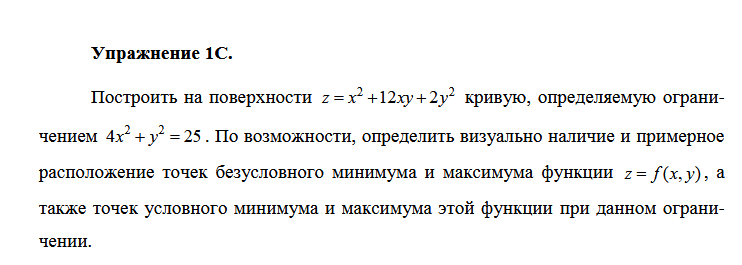

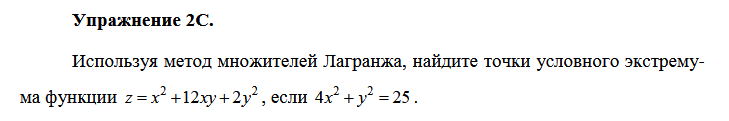

Точка (x=-3/2, y=-4) - условный максимум.
Точка (x=3/2, y=4) - условный максимум.
Точка (x=-2, y=3) - условный минимум.
Точка (x=2, y=-3) - условный минимум.


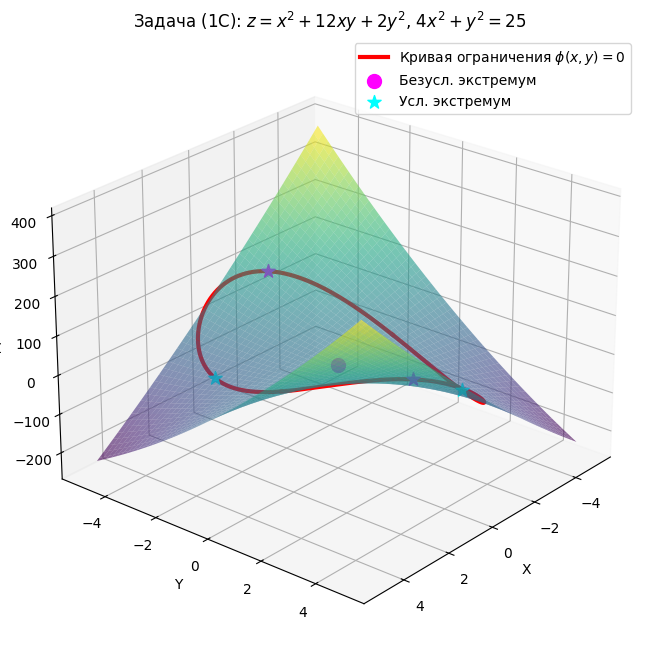

In [72]:
x,y = sp.symbols('x y')
f_expr = x**2 + 12*x*y + 2*y**2
phi_expr = 4*x**2+y**2-25
title = "Задача (1С): $z = x^2 + 12xy + 2y^2$, $4x^2 + y^2 = 25$"
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)

f_grad = [sp.diff(f_expr, var) for var in (x, y)]
uncond_pts = sp.solve(f_grad, (x, y), dict=True)
types = []
f_xx = sp.diff(f_expr, x, 2)
f_yy = sp.diff(f_expr, y, 2)
f_xy = sp.diff(f_expr, x, y)

H = sp.Matrix([[f_xx, f_xy], [f_xy, f_yy]])
det_H = H.det()
for pt in uncond_pts:
    A_val = float(f_xx.subs(pt))
    det_val = float(det_H.subs(pt))
    z_val = float(f_expr.subs(pt))
    
    if det_val > 0:
        res_type = "min" if A_val > 0 else "max"
    elif det_val < 0:
        res_type = "Saddle point"
    else:
        res_type = "undefined"
    types.append(res_type)

lam = sp.symbols('lam')
L = f_expr + lam * phi_expr
L_grad = [sp.diff(L, var) for var in (x, y, lam)]
cond_pts = sp.solve(L_grad, (x, y, lam), dict=True)
types = []
for pt in cond_pts:
    subss = {x: pt[x], y: pt[y], lam: pt[lam]}
    matr = sp.Matrix([[0, sp.diff(phi_expr, x).subs(subss), sp.diff(phi_expr, y).subs(subss)],
                      [sp.diff(phi_expr, x).subs(subss), sp.diff(L, x, x).subs(subss), sp.diff(L, x, y).subs(subss)],
                      [sp.diff(phi_expr, y).subs(subss), sp.diff(L, x, y).subs(subss), sp.diff(L, y, y).subs(subss)]])
    det = -matr.det()
    if det > 0:
        types.append("min")
        print(f"Точка (x={pt[x]}, y={pt[y]}) - условный минимум.")
    elif det < 0:
        types.append("max")
        print(f"Точка (x={pt[x]}, y={pt[y]}) - условный максимум.")
    else:
        types.append("indeterminate")
        print(f"Точка (x={pt[x]}, y={pt[y]}) - неопределенный тип экстремума.")

X, Y = np.meshgrid(x_range, y_range)
f_func = sp.lambdify((x, y), f_expr, 'numpy')
Z = f_func(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, antialiased=True)

x_c = np.linspace(-2.5, 2.5, 10000)
y_c = np.sqrt(25 - 4*x_c**2)

z_c = f_func(x_c, y_c)
ax.plot(x_c, y_c, z_c, color='red', lw=3, label=r'Кривая ограничения $\phi(x,y)=0$')
ax.plot(x_c, -y_c, f_func(x_c, -y_c), color='red', lw=3)

for pt in uncond_pts:
    zv = float(f_expr.subs(pt))
    color = 'blue' if types[uncond_pts.index(pt)] == "min" else 'magenta' if types[uncond_pts.index(pt)] == "max" else 'yellow' if types[uncond_pts.index(pt)] == "Saddle point" else 'gray'
    ax.scatter(float(pt[x]), float(pt[y]), zv, color=color, s=100, label='Безусл. экстремум')

for pt in cond_pts:
    zv = float(f_expr.subs({x: pt[x], y: pt[y]}))
    color = 'magenta' if types[cond_pts.index(pt)] == "max" else 'cyan' if types[cond_pts.index(pt)] == "min" else 'yellow'
    ax.scatter(float(pt[x]), float(pt[y]), zv, color=color, s=100, marker='*', label='Усл. экстремум')

ax.set_title(title)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(elev=25, azim=40)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.show()